# Texas Data Center Siting Analysis

Map data center locations, substations, transmission lines, and natural gas pipelines. Overlay with county-level electricity prices, renewable energy generation, and grid congestion to analyze feasibility of siting data centers across Texas.

## Setup

Run this once to install dependencies (if needed):

```bash
pip install pandas geopandas shapely matplotlib contextily scikit-learn openpyxl
```

**Important:** Open and run this notebook from the `Data_Centre_Sub` folder so file paths resolve correctly.

In [ ]:
# (Cell removed - age derivation moved to Load core layers cell)

In [14]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import contextily as ctx
from pathlib import Path
import numpy as np

BASE = Path(".").resolve()  # Run notebook from Data_Centre_Sub folder

plt.style.use("seaborn-v0_8-whitegrid")

def parse_centroid(col):
    """Parse 'lon, lat' or 'lat, lon' strings into Shapely Points."""
    def _to_point(s):
        if pd.isna(s):
            return None
        s = str(s).replace("�", "-").replace("−", "-").strip()
        parts = [p.strip() for p in s.split(",")]
        if len(parts) != 2:
            return None
        try:
            a, b = float(parts[0]), float(parts[1])
        except ValueError:
            return None
        # Texas region: lat 25-37, lon -107 to -93
        if -110 <= a <= -90 and 25 <= b <= 40:
            return Point(a, b)  # lon, lat
        if 25 <= a <= 40 and -110 <= b <= -90:
            return Point(b, a)  # lat, lon -> lon, lat
        return Point(a, b)  # assume lon, lat
    return col.apply(_to_point)

def to_gdf(df, centroid_col="Centroid", crs="EPSG:4326"):
    geom = parse_centroid(df[centroid_col])
    gdf = gpd.GeoDataFrame(df.copy(), geometry=geom, crs=crs)
    return gdf.dropna(subset=["geometry"])

# Texas bounding box (lon, lat) - excludes OK, LA, NM, etc.
TEXAS_BBOX = {"minx": -106.65, "miny": 25.84, "maxx": -93.51, "maxy": 36.5}

def filter_texas_only(gdf):
    """Keep only points within Texas."""
    if gdf.empty:
        return gdf
    gdf = gdf.to_crs(4326)
    x = gdf.geometry.x
    y = gdf.geometry.y
    mask = (x >= TEXAS_BBOX["minx"]) & (x <= TEXAS_BBOX["maxx"]) & (y >= TEXAS_BBOX["miny"]) & (y <= TEXAS_BBOX["maxy"])
    return gdf[mask].copy()

print("Imports and helpers loaded.")

Imports and helpers loaded.


In [ ]:
# Load core layers

dc_xls = pd.ExcelFile(BASE / "data_centres_doe_texas.xlsx")
data_centres = dc_xls.parse("Data_Centres")

gdf_data_centres = to_gdf(data_centres)
gdf_data_centres["Total MW"] = pd.to_numeric(gdf_data_centres["Total MW"], errors="coerce")

# NERC reserve margins (regional adequacy)
reserve_margins = dc_xls.parse("NERC_RESERVE_MARGINS")
gdf_reserve = to_gdf(reserve_margins)
gdf_reserve["NERC Reserve Margins"] = pd.to_numeric(
    gdf_reserve["NERC Reserve Margins"], errors="coerce"
)

# Power plants (incl renewables)
plants = pd.read_csv(BASE / "power_plants_texas (1).csv")
gdf_plants = to_gdf(plants)
gdf_plants["nameplate_capacity_mw (MW)"] = pd.to_numeric(
    gdf_plants["nameplate_capacity_mw (MW)"], errors="coerce"
)

renewable_mask = gdf_plants["technology"].str.contains(
    "Solar|Wind|Hydro|Geothermal", case=False, na=False
)
gdf_plants["is_renewable"] = renewable_mask

# Texas only: filter by state/bbox
gdf_data_centres = filter_texas_only(gdf_data_centres)
gdf_reserve = filter_texas_only(gdf_reserve)
gdf_plants = gdf_plants[gdf_plants["plant_state"] == "TX"].copy() if "plant_state" in gdf_plants.columns else filter_texas_only(gdf_plants)

print(f"Data centres (TX only): {len(gdf_data_centres)}")
print(f"Power plants (TX only): {len(gdf_plants)}, renewables: {gdf_plants['is_renewable'].sum()}")

Data centres (TX only): 64
Power plants (TX only): 3105, renewables: 714


In [16]:
# Load infrastructure layers

pipelines = pd.read_csv(
    BASE / "natural_gas_interstate_and_intrastate_pipelines_texas (1).csv"
)
gdf_pipelines = to_gdf(pipelines)

tx_lines = pd.read_csv(BASE / "transmission_lines texas (1).csv")
gdf_lines = to_gdf(tx_lines)

fiber = pd.read_csv(BASE / "fiber_optic_cables texas (1).csv")
gdf_fiber = to_gdf(fiber)

rail = pd.read_csv(BASE / "railroads (1).csv")
gdf_rail = to_gdf(rail)

doe_sites = pd.read_csv(BASE / "doe_sites_for_consideration (1) (1).csv")
gdf_doe_sites = to_gdf(doe_sites)

# Texas only: filter all infrastructure to Texas bbox; DOE sites by state
gdf_pipelines = filter_texas_only(gdf_pipelines)
gdf_lines = filter_texas_only(gdf_lines)
gdf_fiber = filter_texas_only(gdf_fiber)
gdf_rail = filter_texas_only(gdf_rail)
gdf_doe_sites = gdf_doe_sites[gdf_doe_sites["state"] == "TX"].copy() if "state" in gdf_doe_sites.columns else filter_texas_only(gdf_doe_sites)

print(f"Pipelines (TX): {len(gdf_pipelines)}, Transmission (TX): {len(gdf_lines)}")
print(f"Fiber (TX): {len(gdf_fiber)}, Rail (TX): {len(gdf_rail)}, DOE sites (TX): {len(gdf_doe_sites)}")

Pipelines (TX): 8108, Transmission (TX): 9063
Fiber (TX): 662, Rail (TX): 9609, DOE sites (TX): 1


In [17]:
# Electricity prices – aggregate by settlement point

price_xls = pd.ExcelFile(BASE / "electricity_prices.xlsx")

price_frames = []
for sheet in price_xls.sheet_names:
    df_m = price_xls.parse(sheet)
    df_m["month"] = sheet
    price_frames.append(df_m)

prices = pd.concat(price_frames, ignore_index=True)
prices["Settlement Point Price"] = pd.to_numeric(
    prices["Settlement Point Price"], errors="coerce"
)

avg_price = (
    prices.groupby("Settlement Point", as_index=False)["Settlement Point Price"]
    .mean()
    .rename(columns={"Settlement Point Price": "avg_price"})
)

print("Average electricity price by settlement point:")
avg_price.sort_values("avg_price", ascending=False).head(10)

Average electricity price by settlement point:


,Settlement Point,avg_price
14,LZ_WEST,42.716087
10,LZ_LCRA,38.166779
8,LZ_CPS,37.088334
7,LZ_AEN,36.940711
9,LZ_HOUSTON,34.566280
1,HB_HOUSTON,34.466994
6,HB_WEST,33.735998
12,LZ_RAYBN,33.682566
2,HB_HUBAVG,33.497153
11,LZ_NORTH,33.401317


In [18]:
# Add nearest-neighbour metrics (reserve margin, renewable capacity)

from sklearn.neighbors import BallTree

def add_nearest_metric(target_gdf, source_gdf, source_col, new_col, k=1):
    target = target_gdf.to_crs(4326)
    source = source_gdf.dropna(subset=[source_col]).to_crs(4326)
    if source.empty:
        target_gdf[new_col] = np.nan
        return target_gdf
    target_coords = np.vstack([target.geometry.y.values, target.geometry.x.values]).T
    source_coords = np.vstack([source.geometry.y.values, source.geometry.x.values]).T
    tree = BallTree(np.radians(source_coords), leaf_size=15, metric="haversine")
    dist, ind = tree.query(np.radians(target_coords), k=k)
    vals = source[source_col].values
    nearest_vals = vals[ind].mean(axis=1)
    target_gdf[new_col] = nearest_vals
    return target_gdf

gdf_data_centres = add_nearest_metric(
    gdf_data_centres, gdf_reserve, "NERC Reserve Margins", "nearest_reserve_margin"
)

renewable_plants = gdf_plants[gdf_plants["is_renewable"]].copy()
gdf_data_centres = add_nearest_metric(
    gdf_data_centres,
    renewable_plants,
    "nameplate_capacity_mw (MW)",
    "nearest_renewable_capacity_mw",
)

gdf_data_centres[["Name", "Total MW", "nearest_reserve_margin", "nearest_renewable_capacity_mw"]].head(10)

,Name,Total MW,nearest_reserve_margin,nearest_renewable_capacity_mw
0,"Andrews County, TX",205.0,0.249,100.0
1,"Baylor County, TX",166.0,0.249,30.2
2,"Bell County, TX",657.0,0.249,350.0
3,"Bexar County, TX",1453.6,0.249,5.0
4,"Bosque County, TX",40.0,0.249,5.0
5,"Bowie County, TX",2.0,0.249,300.0
6,"Brazos County, TX",6.0,0.249,210.0
7,"Briscoe County, TX",100.0,0.249,150.0
8,"Caddo Parish, LA",0.9,0.249,3.0
9,"Caldwell County, TX",144.0,0.249,200.0


In [19]:
def texas_extent_3857(gdf_list):
    """Compute extent in Web Mercator (meters) for proper basemap alignment."""
    gdfs_3857 = [g.to_crs(epsg=3857) for g in gdf_list if not g.empty]
    if not gdfs_3857:
        # Default Texas extent in 3857 (meters)
        return (-11900000, 3000000, -10400000, 4400000)
    all_bounds = [g.total_bounds for g in gdfs_3857]
    xmin = min(b[0] for b in all_bounds)
    ymin = min(b[1] for b in all_bounds)
    xmax = max(b[2] for b in all_bounds)
    ymax = max(b[3] for b in all_bounds)
    return xmin, ymin, xmax, ymax

def setup_tx_plot(gdfs, figsize=(10, 10), title=None):
    """Create figure with axes in Web Mercator (EPSG:3857) for contextily basemap."""
    fig, ax = plt.subplots(figsize=figsize, dpi=130)
    xmin, ymin, xmax, ymax = texas_extent_3857(gdfs)
    buffer_m = 50000  # ~50 km buffer in meters
    ax.set_xlim(xmin - buffer_m, xmax + buffer_m)
    ax.set_ylim(ymin - buffer_m, ymax + buffer_m)
    ax.set_aspect("equal")
    if title:
        ax.set_title(title, fontsize=14, fontweight="bold")
    return fig, ax

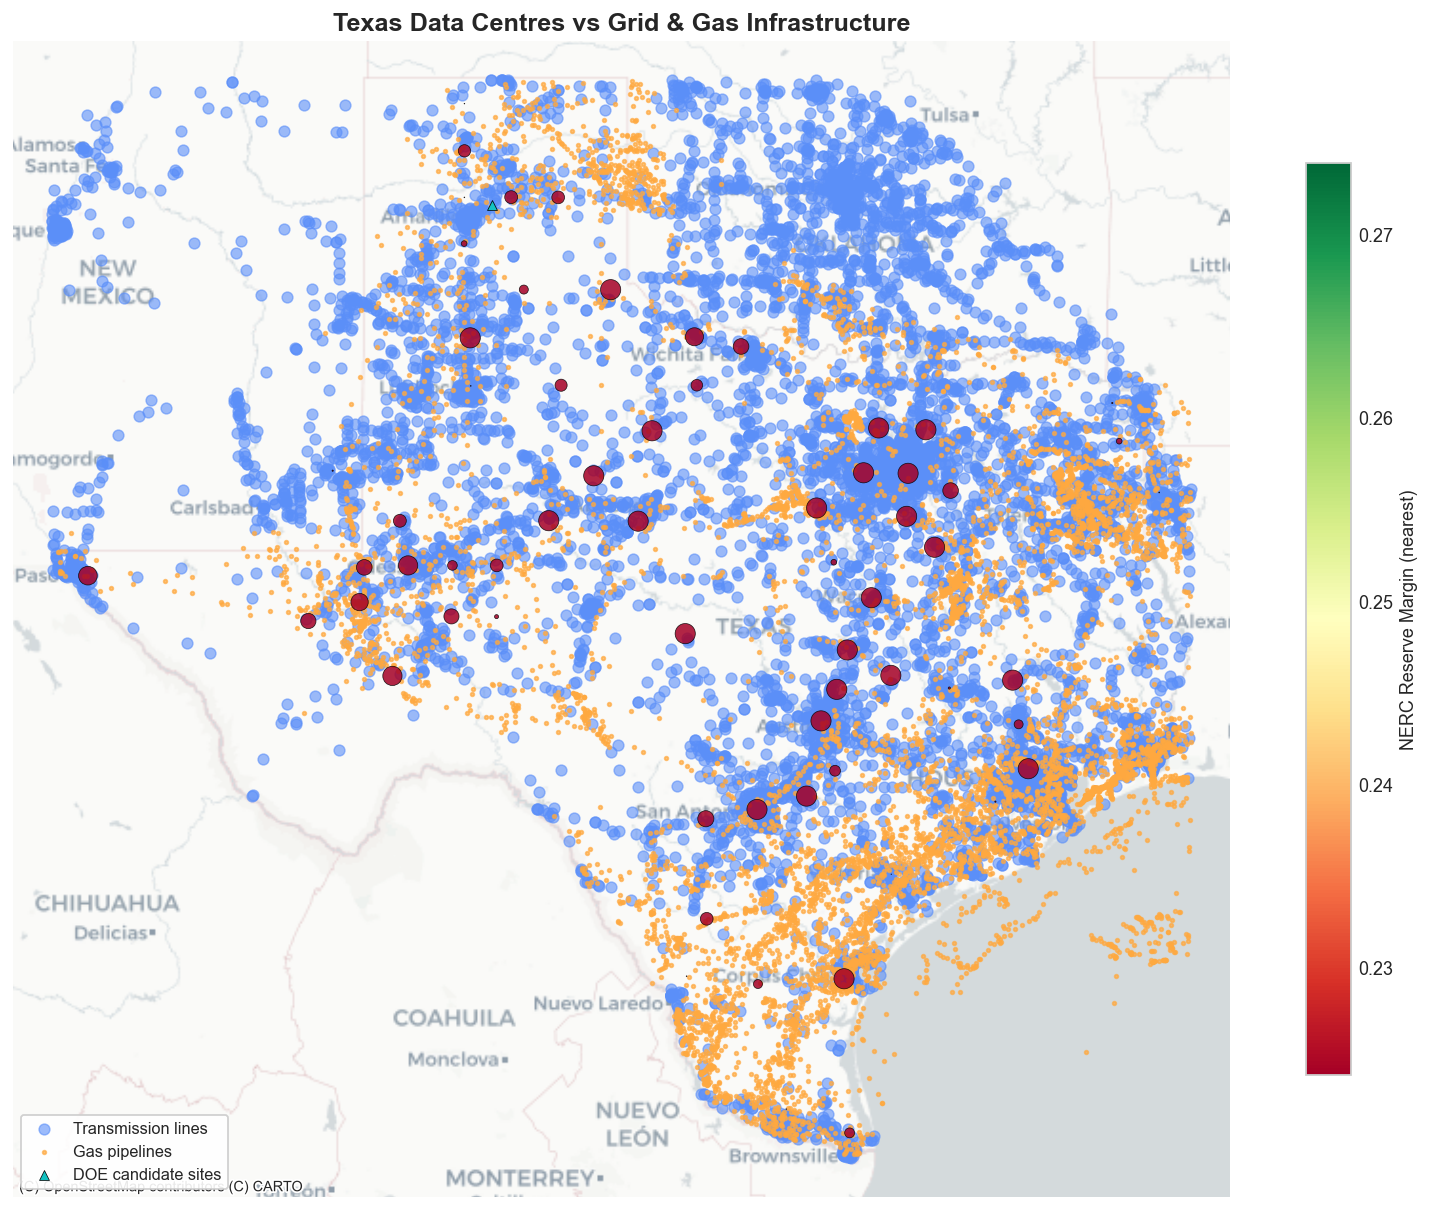

In [20]:
# Map: Data centres vs transmission lines + gas pipelines + DOE sites

gdfs_for_extent = [gdf_data_centres, gdf_lines, gdf_pipelines, gdf_doe_sites]

fig, ax = setup_tx_plot(
    gdfs_for_extent,
    figsize=(12, 12),
    title="Texas Data Centres vs Grid & Gas Infrastructure",
)

gdc = gdf_data_centres.to_crs(epsg=3857)
glines = gdf_lines.to_crs(epsg=3857)
gpipe = gdf_pipelines.to_crs(epsg=3857)
gdoe = gdf_doe_sites.to_crs(epsg=3857)

glines.plot(ax=ax, linewidth=0.8, color="#5b8ff9", alpha=0.6, label="Transmission lines")
gpipe.plot(ax=ax, markersize=4, color="#ffa940", alpha=0.7, label="Gas pipelines")
gdoe.plot(ax=ax, markersize=30, marker="^", color="#13c2c2", edgecolor="black",
          linewidth=0.4, label="DOE candidate sites")

gdc.plot(
    ax=ax,
    column="nearest_reserve_margin",
    cmap="RdYlGn",
    markersize=gdc["Total MW"].fillna(0).clip(upper=500) * 0.25,
    alpha=0.85,
    edgecolor="black",
    linewidth=0.4,
    legend=True,
    legend_kwds={"label": "NERC Reserve Margin (nearest)", "shrink": 0.6},
)

ctx.add_basemap(ax, crs="EPSG:3857", source=ctx.providers.CartoDB.Positron)

ax.legend(loc="lower left", frameon=True, framealpha=0.9, facecolor="white", fontsize=9)
ax.axis("off")
plt.tight_layout()
plt.show()

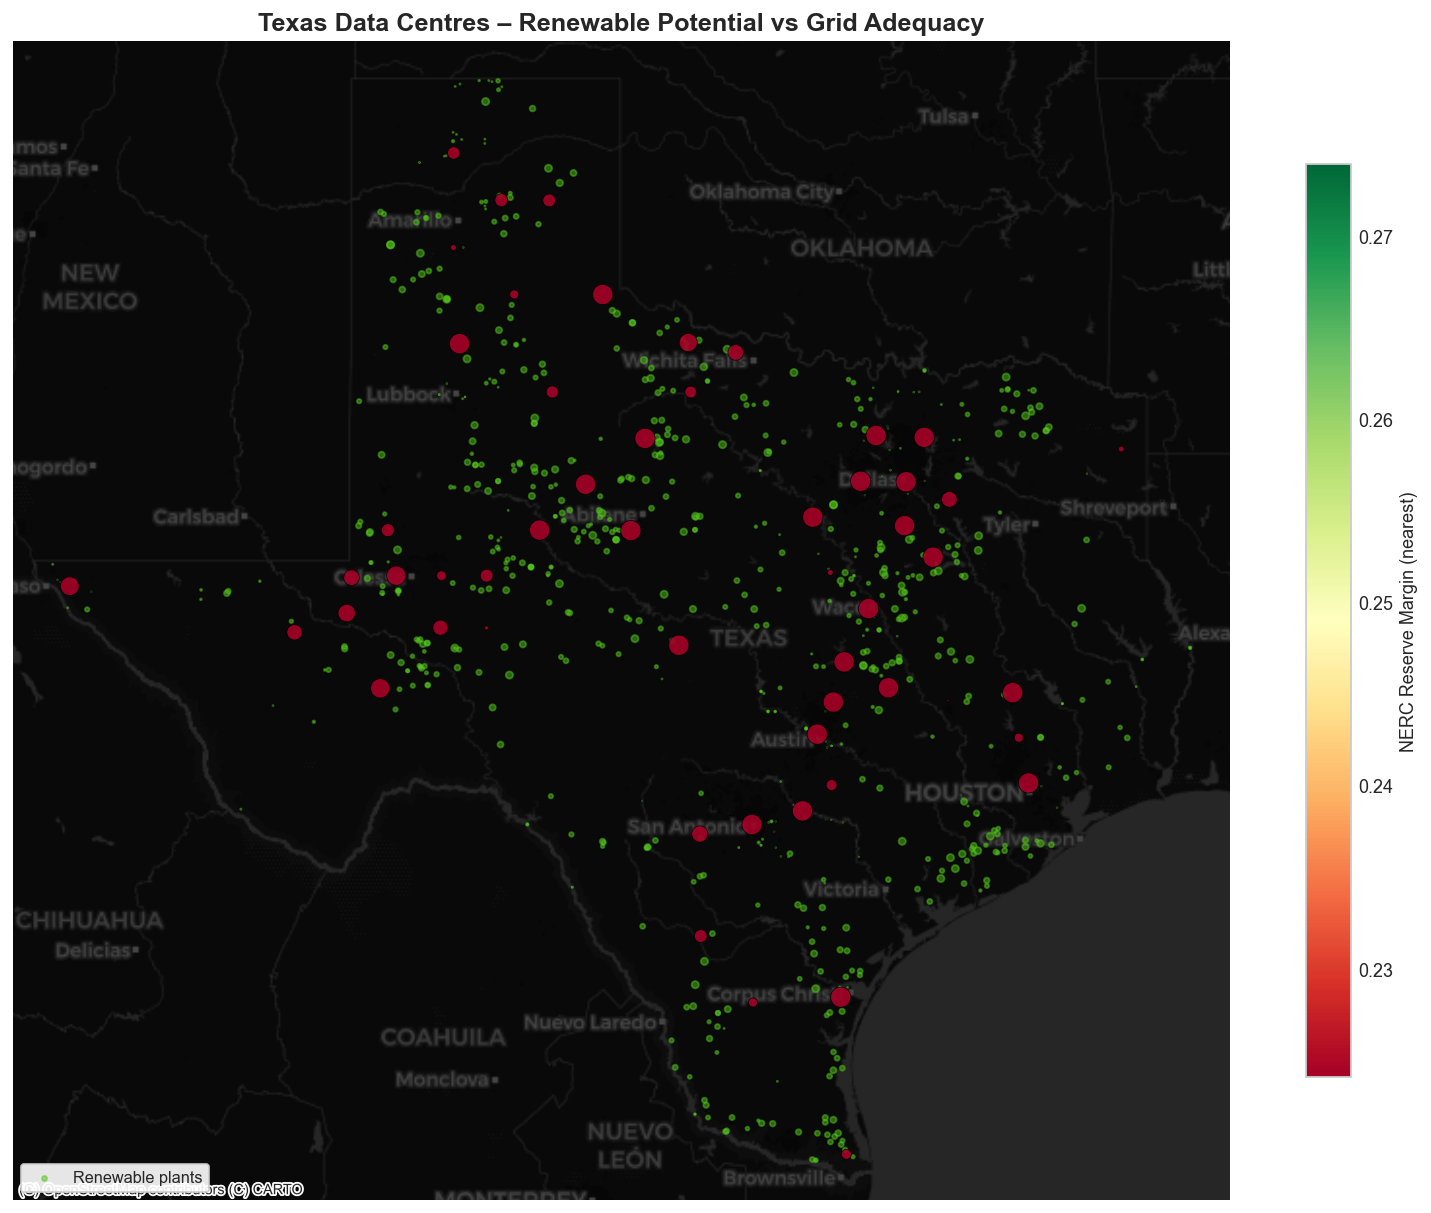

In [21]:
# Map: Renewable potential vs grid adequacy

renewable_plants_3857 = renewable_plants.to_crs(epsg=3857)
gdc2 = gdf_data_centres.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 12), dpi=130)
xmin, ymin, xmax, ymax = texas_extent_3857([gdf_data_centres, renewable_plants])
ax.set_xlim(xmin - 50000, xmax + 50000)
ax.set_ylim(ymin - 50000, ymax + 50000)
ax.set_aspect("equal")
ax.set_title(
    "Texas Data Centres – Renewable Potential vs Grid Adequacy",
    fontsize=14,
    fontweight="bold",
)

renewable_plants_3857.plot(
    ax=ax,
    markersize=renewable_plants_3857["nameplate_capacity_mw (MW)"].fillna(0).clip(upper=400) * 0.04,
    color="#52c41a",
    alpha=0.5,
    label="Renewable plants",
)

gdc2.plot(
    ax=ax,
    column="nearest_reserve_margin",
    cmap="RdYlGn",
    markersize=gdc2["Total MW"].fillna(0).clip(upper=500) * 0.25,
    alpha=0.9,
    edgecolor="black",
    linewidth=0.4,
    legend=True,
    legend_kwds={"label": "NERC Reserve Margin (nearest)", "shrink": 0.6},
)

ctx.add_basemap(ax, crs="EPSG:3857", source=ctx.providers.CartoDB.DarkMatter)
ax.axis("off")
ax.legend(loc="lower left", frameon=True, framealpha=0.9, facecolor="white", fontsize=9)
plt.tight_layout()
plt.show()

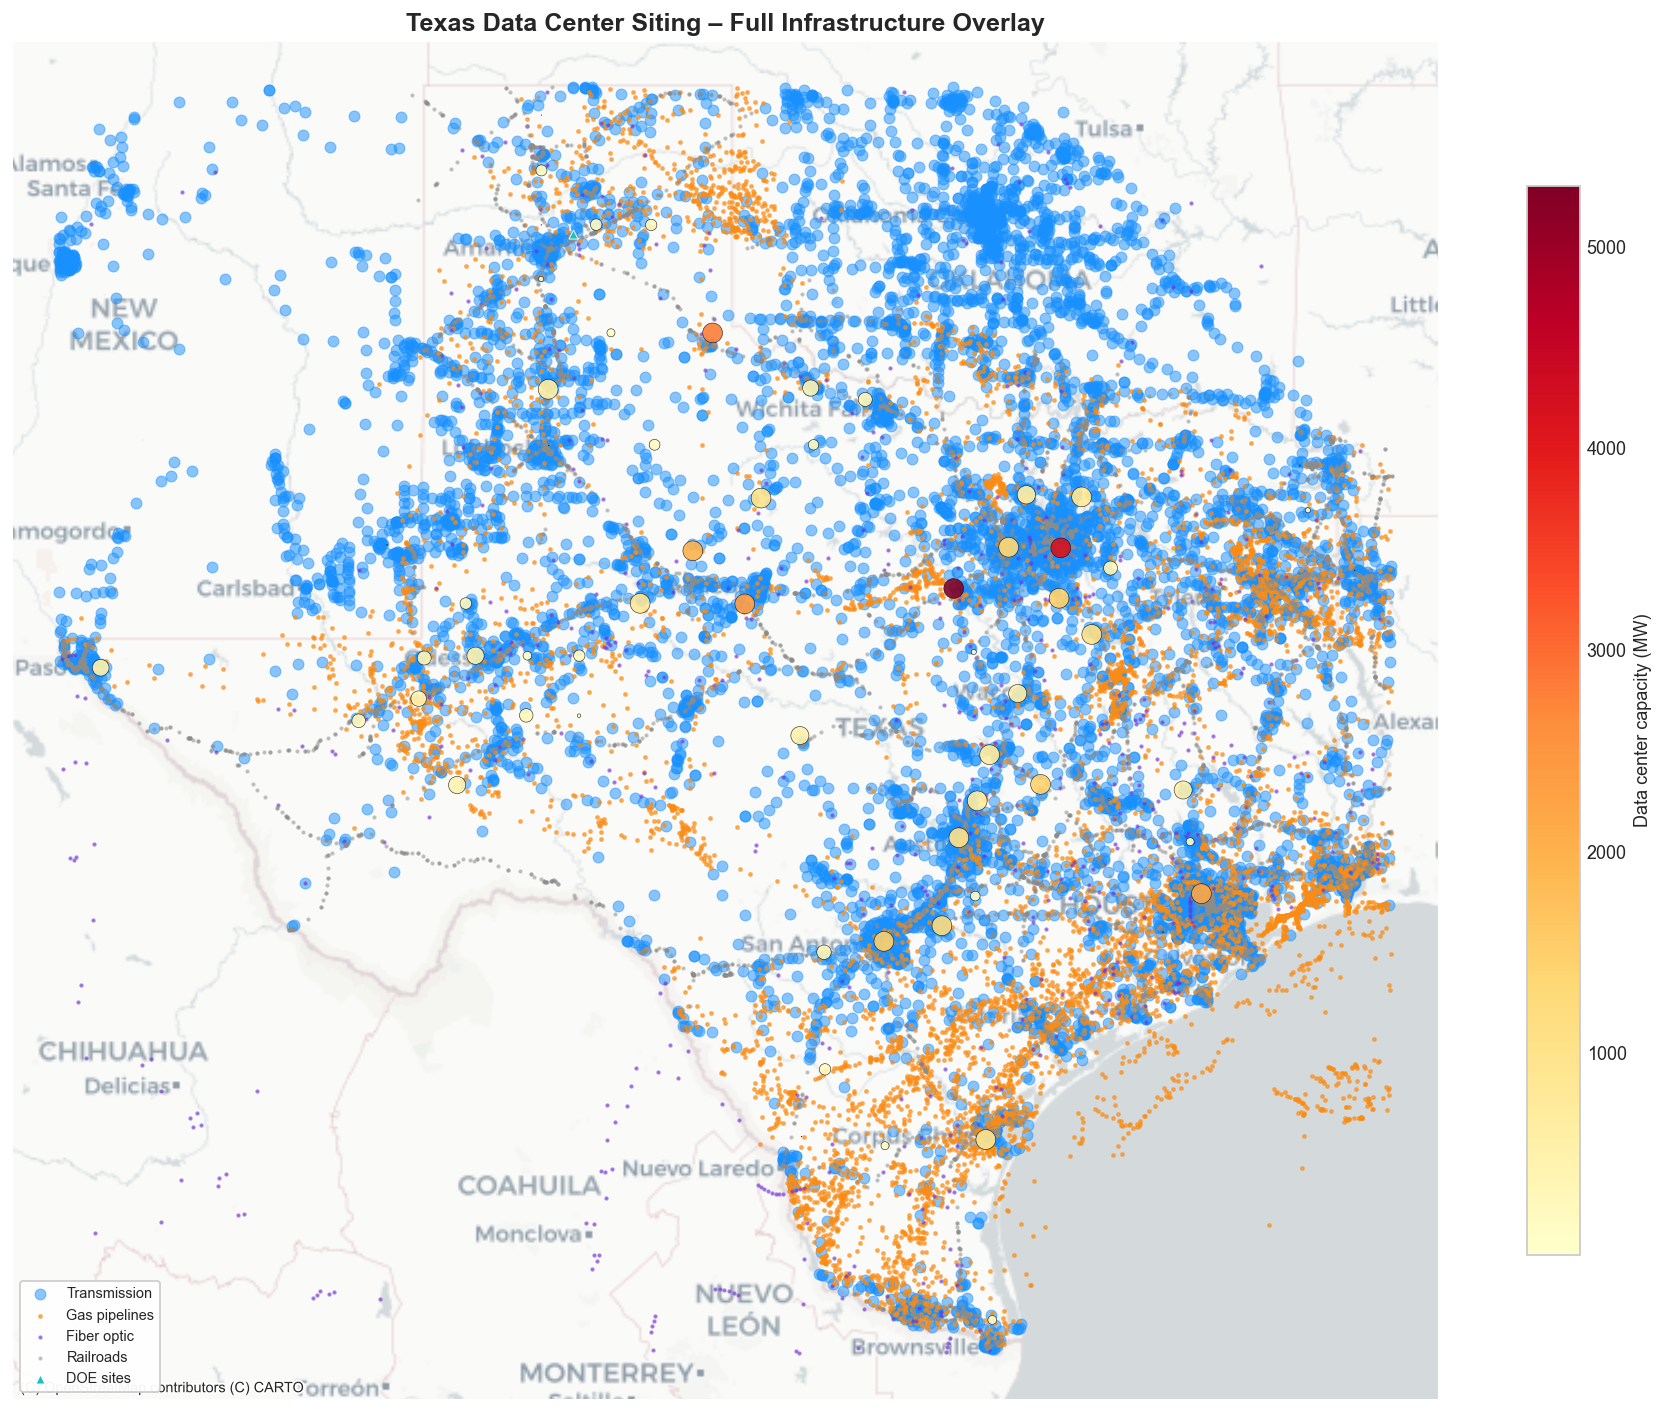

In [22]:
# Map: All layers – data centres, transmission, pipelines, fiber, rail

all_gdfs = [gdf_data_centres, gdf_lines, gdf_pipelines, gdf_fiber, gdf_rail, gdf_doe_sites]

fig, ax = plt.subplots(figsize=(14, 14), dpi=130)
ax.set_title(
    "Texas Data Center Siting – Full Infrastructure Overlay",
    fontsize=14,
    fontweight="bold",
)

xmin, ymin, xmax, ymax = texas_extent_3857(all_gdfs)
ax.set_xlim(xmin - 50000, xmax + 50000)
ax.set_ylim(ymin - 50000, ymax + 50000)
ax.set_aspect("equal")

gdc = gdf_data_centres.to_crs(epsg=3857)
glines = gdf_lines.to_crs(epsg=3857)
gpipe = gdf_pipelines.to_crs(epsg=3857)
gfiber = gdf_fiber.to_crs(epsg=3857)
grail = gdf_rail.to_crs(epsg=3857)
gdoe = gdf_doe_sites.to_crs(epsg=3857)

glines.plot(ax=ax, linewidth=0.6, color="#1890ff", alpha=0.5, label="Transmission")
gpipe.plot(ax=ax, markersize=3, color="#fa8c16", alpha=0.6, label="Gas pipelines")
gfiber.plot(ax=ax, markersize=2, color="#722ed1", alpha=0.5, label="Fiber optic")
grail.plot(ax=ax, markersize=2, color="#8c8c8c", alpha=0.4, label="Railroads")
gdoe.plot(ax=ax, markersize=25, marker="^", color="#13c2c2", edgecolor="white",
          linewidth=0.5, label="DOE sites")

gdc.plot(
    ax=ax,
    column="Total MW",
    cmap="YlOrRd",
    markersize=gdc["Total MW"].fillna(0).clip(upper=600) * 0.2,
    alpha=0.9,
    edgecolor="black",
    linewidth=0.3,
    legend=True,
    legend_kwds={"label": "Data center capacity (MW)", "shrink": 0.6},
)

ctx.add_basemap(ax, crs="EPSG:3857", source=ctx.providers.CartoDB.Positron)
ax.legend(loc="lower left", frameon=True, framealpha=0.95, facecolor="white", fontsize=8)
ax.axis("off")
plt.tight_layout()
plt.show()